In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/customer-churn.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

Series([], dtype: int64)

In [8]:
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

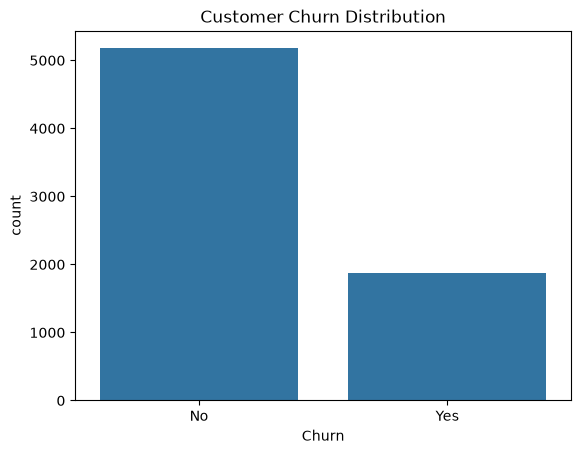

In [9]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

In [10]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical:")
print(categorical_cols)

print("\nNumerical:")
print(numerical_cols)

Categorical:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Numerical:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [12]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [13]:
df.dropna(inplace=True)

print("Shape after dropping null values:", df.shape)
df.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:", df.shape)
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


Shape after dropping null values: (7043, 21)
Shape after dropping duplicates: (7043, 21)


Series([], dtype: int64)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

# Work on a copy so the raw dataframe remains available for reference.
clean_df = df.copy()

# TotalCharges contains numeric amounts and blank strings, not categories.
# Leave missing amounts for the training-fitted median imputer.
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")

# Drop the customer identifier.
clean_df = clean_df.drop(columns=["customerID"], errors="ignore")


# Normalize the target representation and remove invalid target rows.
clean_df["Churn"] = clean_df["Churn"].astype(str).str.strip().str.lower()
valid_targets = {"0", "1", "true", "false", "yes", "no"}
clean_df = clean_df[clean_df["Churn"].isin(valid_targets)].copy()
clean_df["Churn"] = clean_df["Churn"].map({"true": 1, "yes": 1, "1": 1, "false": 0, "no": 0, "0": 0}).astype(int)

# Remove duplicate records before splitting the data.
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

X = clean_df.drop(columns="Churn")
y = clean_df["Churn"]

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.5, random_state=42, stratify=y_holdout
)

# Infer feature groups from training data only.
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
category_counts = X_train[categorical_features].nunique()
binary_categorical_features = category_counts[category_counts == 2].index.tolist()
one_hot_features = category_counts[category_counts != 2].index.tolist()

# Map two-category features directly to one 0/1 column.
# Sorted categories give No=0 / Yes=1 and Female=0 / Male=1.
binary_mappings = {
    column: {value: code for code, value in enumerate(sorted(X_train[column].dropna().unique()))}
    for column in binary_categorical_features
}
X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()
for column, mapping in binary_mappings.items():
    for split in (X_train, X_val, X_test):
        # Missing or unseen values are handled by the training-fitted imputer.
        split[column] = split[column].map(mapping)

# Already-numeric indicators (SeniorCitizen) also remain single binary columns.
binary_numeric_features = [
    column for column in X_train.select_dtypes(include="number").columns
    if column not in binary_categorical_features
    and set(X_train[column].dropna().unique()) == {0, 1}
]
binary_features = binary_categorical_features + binary_numeric_features
numerical_features = [
    column for column in X_train.select_dtypes(include="number").columns
    if column not in binary_features
]

# Fit imputers and encoders on training data only to prevent data leakage.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numerical_features,
        ),
        (
            "binary",
            SimpleImputer(strategy="most_frequent"),
            binary_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                # Three- and four-category features keep one column per category.
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            one_hot_features,
        ),
    ],
    remainder="drop",
)

X_train_standardized = preprocessor.fit_transform(X_train)
X_val_standardized = preprocessor.transform(X_val)
X_test_standardized = preprocessor.transform(X_test)

# Normalization rescales every transformed feature to the [0, 1] range.
normalizer = MinMaxScaler()
X_train_normalized = normalizer.fit_transform(X_train_standardized)
X_val_normalized = normalizer.transform(X_val_standardized)
X_test_normalized = normalizer.transform(X_test_standardized)

feature_names = preprocessor.get_feature_names_out()


def as_feature_frame(values, index):
    return pd.DataFrame(values, columns=feature_names, index=index)


X_train_standardized = as_feature_frame(X_train_standardized, X_train.index)
X_val_standardized = as_feature_frame(X_val_standardized, X_val.index)
X_test_standardized = as_feature_frame(X_test_standardized, X_test.index)
X_train_normalized = as_feature_frame(X_train_normalized, X_train.index)
X_val_normalized = as_feature_frame(X_val_normalized, X_val.index)
X_test_normalized = as_feature_frame(X_test_normalized, X_test.index)

# Public outputs: normalized features and encoded target labels.
X_train = X_train_normalized
X_val = X_val_normalized
X_test = X_test_normalized
Y_train = y_train
Y_val = y_val
Y_test = y_test

print("Clean data shape:", clean_df.shape)
print("Binary category mappings:", binary_mappings)
print("Already-numeric binary columns:", binary_numeric_features)
print("One-hot encoded columns:", one_hot_features)
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test.shape)
print("Missing values after preprocessing:", X_train.isna().sum().sum())
print("Normalized feature range:", (X_train.min().min(), X_train.max().max()))
X_train.head()

Clean data shape: (7021, 20)
Binary category mappings: {'gender': {'Female': 0, 'Male': 1}, 'Partner': {'No': 0, 'Yes': 1}, 'Dependents': {'No': 0, 'Yes': 1}, 'PhoneService': {'No': 0, 'Yes': 1}, 'PaperlessBilling': {'No': 0, 'Yes': 1}}
Already-numeric binary columns: ['SeniorCitizen']
One-hot encoded columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Training shape: (5616, 40)
Validation shape: (702, 40)
Testing shape: (703, 40)
Missing values after preprocessing: 0
Normalized feature range: (0.0, 1.0)


,numerical__tenure,numerical__MonthlyCharges,numerical__TotalCharges,binary__gender,binary__Partner,binary__Dependents,binary__PhoneService,binary__PaperlessBilling,binary__SeniorCitizen,categorical__MultipleLines_No,...,categorical__StreamingMovies_No,categorical__StreamingMovies_No internet service,categorical__StreamingMovies_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check
2624,0.027778,0.521891,0.014061,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2645,0.208333,0.657711,0.148143,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1416,0.930556,0.709453,0.733243,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5760,0.069444,0.471144,0.037047,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2420,0.361111,0.020398,0.056820,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [17]:
# Final quality checks for the six public output variables.
assert clean_df.duplicated().sum() == 0
assert clean_df["gender"].astype("string").str.strip().str.lower().ne("other").all()
assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert len(X_train) + len(X_val) + len(X_test) == len(clean_df)
assert X_train.index.intersection(X_val.index).empty
assert X_train.index.intersection(X_test.index).empty
assert X_val.index.intersection(X_test.index).empty
assert X_train.min().min() >= 0
assert X_train.max().max() <= 1 + 1e-12
assert len(X_train) == len(Y_train)
assert len(X_val) == len(Y_val)
assert len(X_test) == len(Y_test)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_val:", Y_val.shape)
print("Y_test:", Y_test.shape)
print("All preprocessing checks passed.")

X_train: (5616, 40)
X_val: (702, 40)
X_test: (703, 40)
Y_train: (5616,)
Y_val: (702,)
Y_test: (703,)
All preprocessing checks passed.


In [19]:
# Save the prepared datasets for use in other notebooks.
np.savez_compressed(
    "../data/processed_datasets.npz",
    X_train=X_train.to_numpy(dtype="float32"),
    X_val=X_val.to_numpy(dtype="float32"),
    X_test=X_test.to_numpy(dtype="float32"),
    Y_train=Y_train.to_numpy(dtype="int8"),
    Y_val=Y_val.to_numpy(dtype="int8"),
    Y_test=Y_test.to_numpy(dtype="int8"),
)
print("Saved processed datasets to data/processed_datasets.npz")

Saved processed datasets to data/processed_datasets.npz
